In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Daten laden
deaths = pd.read_csv('Deaths_1x1.txt', sep = '\s+', skiprows = 2)
exposures = pd.read_csv('Exposures_1x1.txt', sep = '\s+', skiprows = 2)

# Zentrale Sterberate
deaths['mx'] = deaths['Total'] / exposures['Total']

# Sterbewahrscheinlichkeit (Näherung)
deaths['qx'] = deaths['mx'] / (1 + 0.5 * deaths['mx'])

print (deaths.head())

   Year Age   Female     Male    Total        mx        qx
0  1990   0  2665.01  3720.02  6385.03  0.007119  0.007094
1  1990   1   269.00   311.00   580.00  0.000647  0.000646
2  1990   2   155.00   213.00   368.00  0.000410  0.000410
3  1990   3   136.00   192.00   328.00  0.000373  0.000373
4  1990   4    87.00   132.00   219.00  0.000258  0.000258


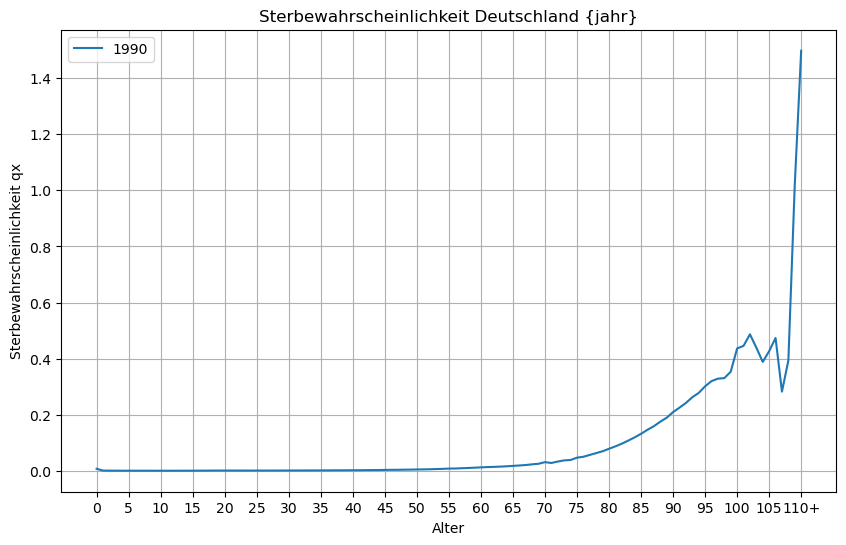

In [61]:
# Sterbekurve für ein einzelnes Jahr
jahr = 1990
df_jahr = deaths[deaths['Year'] == jahr]

plt.figure(figsize = (10, 6))
plt.plot(df_jahr['Age'], df_jahr['qx'], label = str(jahr))
plt.xlabel('Alter')
plt.ylabel('Sterbewahrscheinlichkeit qx')
plt.title('Sterbewahrscheinlichkeit Deutschland {jahr}')
plt.xticks(range(0, 111, 5))
plt.legend()
plt.grid(True)
plt.show()

Unregelmäßigkeiten ab 100: Sehr wenige Beobachtungen, zufällige Schwankungen dominieren. Evtl. separat behandeln oder glätten.

Knick bei ~70: Wiedervereinigungseffekt. Die DDR-Bevölkerung hatte 1990 eine andere Altersstruktur und andere Sterbewahrscheinlichkeiten, besonders in der älteren Generation. Das ist ein echtes demographisches Signal, kein Datenfehler.

Abflachung 96-98: Bekanntes Phänomen (“late-life mortality deceleration”). Theorie: die Schwächsten sterben früher, ab ~95 überleben nur noch die Robustesten, dadurch wächst die Sterberate dann langsamer. (https://en.wikipedia.org/wiki/Late-life_mortality_deceleration)

Zur besseren Interpretierbarkeit verwenden wir nun qx (log)

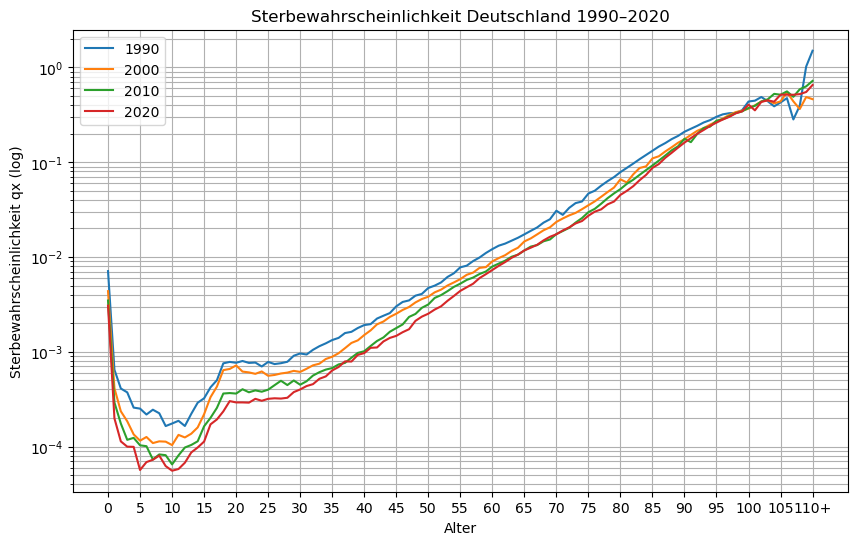

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))

for jahr in [1990, 2000, 2010, 2020]:
    df_jahr = deaths[deaths['Year'] == jahr]
    ax.plot(df_jahr['Age'], df_jahr['qx'], label=str(jahr))

ax.set_xlabel('Alter')
ax.set_ylabel('Sterbewahrscheinlichkeit qx (log)')
ax.set_title('Sterbewahrscheinlichkeit Deutschland 1990–2020')
ax.set_yscale('log')
ax.set_xticks(range(0, 111, 5))
ax.legend()
ax.grid(True, which = 'both')
plt.show()

Rasanter Abfall 0-10: Säuglingssterblichkeit ist hoch, danach das “gesündeste” Lebensjahrzehnt.

Anstieg bis 18, Plateau bis 30: Das sogenannte “accident hump”. erhöhte Sterblichkeit junger Männer durch Unfälle, Risikoverhalten. In der log-Darstellung gut sichtbar. (https://www.demogr.mpg.de/en/news_events_6123/news_press_releases_4630/news/aging_by_accident_5842)

Fast linearer Anstieg ab 30 in log-Skala: Gompertz-Verteilung. Linear in log = exponentielles Wachstum der Sterblichkeit mit dem Alter. Fundamentales Gesetz der Alterssterblichkeit seit 1825. (https://en.wikipedia.org/wiki/Gompertz_function)

Absenkung stärker bei Kindern als bei Älteren: Medizinischer Fortschritt wirkt stärker bei vermeidbaren Todesursachen (z. B. Infektionen, Geburten) als bei degenerativen Erkrankungen im Alter.

Wandernder Knick 1990→2020 von 70 auf 80 bzw. 90: Wiedervereinigungseffekt der sich über die Kohorten verschiebt.

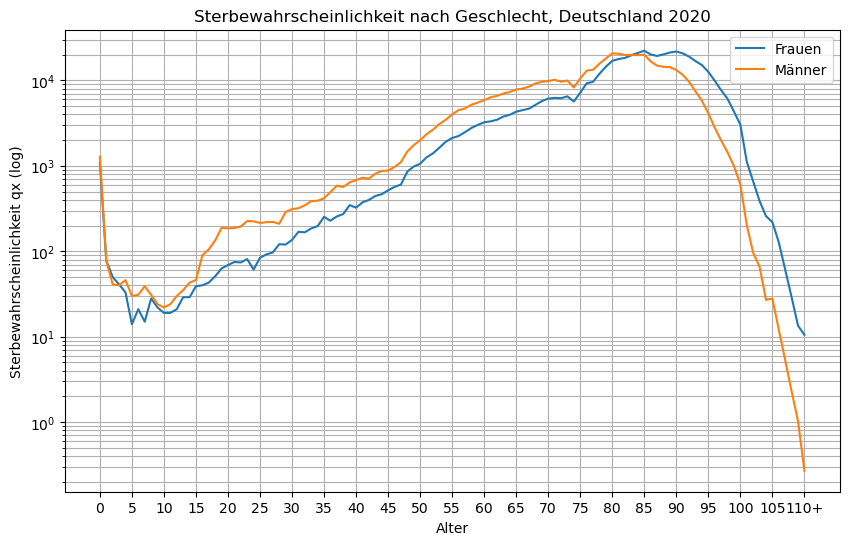

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))

df_2020 = deaths[deaths['Year'] == 2020]

ax.plot(df_2020['Age'], df_2020['Female'], label='Frauen')
ax.plot(df_2020['Age'], df_2020['Male'], label='Männer')

ax.set_xlabel('Alter')
ax.set_ylabel('Sterbewahrscheinlichkeit qx (log)')
ax.set_title('Sterbewahrscheinlichkeit nach Geschlecht, Deutschland 2020')
ax.set_yscale('log')
ax.set_xticks(range(0, 111, 5))
ax.legend()
ax.grid(True, which='both')
plt.show()

Säuglingssterblichkeit identisch: Geschlechterunterschiede in der Sterblichkeit entwickeln sich erst später.

Männer durchgehend höher: Bekannt als “male-female mortality gap”. Eine Kombination aus biologischen Faktoren (z. B. Hormone, Immunsystem) und Verhalten (z. B. Risikoverhalten, weniger Arztbesuche).

Annäherung ab 70, Umkehr ab 84: Wieder “late-life mortality deceleration”, Männer mit hohem Risiko sind bereits gestorben. Ab 84 überleben nur noch die robustesten Männer, die dann tatsächlich langlebiger sind als die verbleibenden Frauen.

Starker Anstieg Männer 15-18: Das ist der "accident hump". Hier aber geschlechtsspezifisch deutlich ausgeprägter. Unfälle, Suizid, Risikoverhalten o. ä. bei jungen Männern. In Deutschland und international gut dokumentiert.

Eine vollständige Sterbetafel berechnet für jeden Jahrgang wie viele von 100.000 Geborenen noch leben. Daraus ergibt sich die Lebenserwartung.

Die Kerngrößen:

•	lx – Anzahl Überlebende im Alter x (beginnt bei l₀ = 100.000)
•	dx – Gestorbene zwischen x und x+1
•	Lx – Gelebte Jahre zwischen x und x+1
•	Tx – Gesamte verbleibende Lebensjahre ab Alter x
•	ex – Lebenserwartung im Alter x

In [73]:
def sterbetafel(qx_series):
    n = len(qx_series)
    l = np.zeros(n)
    d = np.zeros(n)
    L = np.zeros(n)
    T = np.zeros(n)
    e = np.zeros(n)
    
    l[0] = 100000
    
    for x in range(n):
        d[x] = l[x] * qx_series.iloc[x]
        if x < n - 1:
            l[x + 1] = l[x] - d[x]
        L[x] = l[x] - 0.5 * d[x]
    
    # Tx von hinten berechnen
    T[n - 1] = L[n - 1]
    for x in range(n - 2, -1, -1):
        T[x] = T[x + 1] + L[x]
    
    e = T / l
    
    return pd.DataFrame({
        'lx': l, 'dx': d, 'Lx': L, 'Tx': T, 'ex': e
    })

# Für 2020
df_2020 = deaths[deaths['Year'] == 2020].reset_index(drop=True)
tafel_2020 = sterbetafel(df_2020['qx'])

print(f"Lebenserwartung bei Geburt 2020: {tafel_2020['ex'].iloc[0]:.2f} Jahre")

Lebenserwartung bei Geburt 2020: 81.02 Jahre


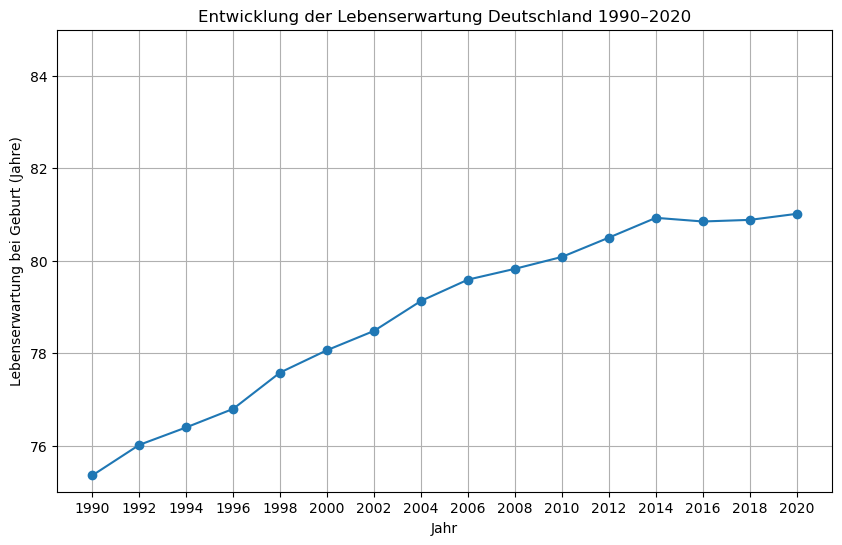

    Jahr  Lebenserwartung
0   1990        75.352145
1   1992        76.013379
2   1994        76.392164
3   1996        76.793398
4   1998        77.580126
5   2000        78.064487
6   2002        78.481461
7   2004        79.130153
8   2006        79.591183
9   2008        79.825283
10  2010        80.082598
11  2012        80.500330
12  2014        80.928462
13  2016        80.849388
14  2018        80.884073
15  2020        81.015187


In [75]:
ergebnisse = []

for jahr in range(1990, 2021, 2):
    df_jahr = deaths[deaths['Year'] == jahr].reset_index(drop = True)
    tafel = sterbetafel(df_jahr['qx'])
    e0 = tafel['ex'].iloc[0]
    ergebnisse.append({'Jahr': jahr, 'Lebenserwartung': e0})

df_e0 = pd.DataFrame(ergebnisse)

plt.figure(figsize = (10, 6))
plt.plot(df_e0['Jahr'], df_e0['Lebenserwartung'], marker='o')
plt.xlabel('Jahr')
plt.ylabel('Lebenserwartung bei Geburt (Jahre)')
plt.title('Entwicklung der Lebenserwartung Deutschland 1990–2020')
plt.grid(True)
plt.xticks(df_e0['Jahr'])
plt.ylim(75, 85)
plt.show()

print(df_e0)


Zur Stagnation ab 2014:

In der demographischen Forschung tatsächlich dokumentiert. Mögliche Ursachen:

•	Hitzewellen 2018, 2019 – erhöhte Sterblichkeit bei Älteren
•	Grippewellen 2017/18 waren ungewöhnlich stark
•	“Low-hanging fruit”-Effekt. Die leicht erreichbaren medizinischen Fortschritte sind ausgeschöpft

2020 leichter Anstieg trotz COVID, paradoxerweise weil andere Todesursachen (Unfälle, Grippe) durch Lockdown zurückgingen

/var/folders/cj/mk7mtcs97kn4r9g133sdfl5m0000gn/T/ipykernel_78565/338400451.py:22: RuntimeWarning: invalid value encountered in divide
  e = T / l


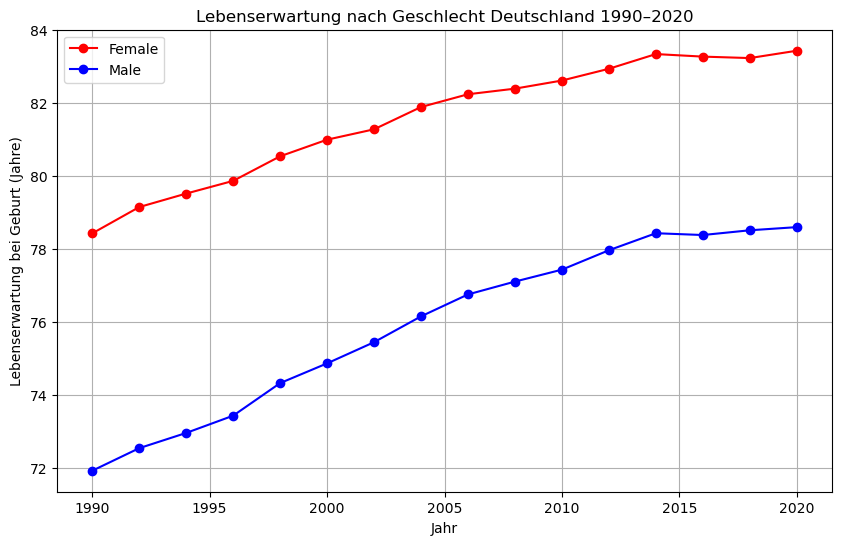

In [82]:
ergebnisse_geschlecht = []

for jahr in range(1990, 2021, 2):
    df_jahr = deaths[deaths['Year'] == jahr].reset_index(drop=True)
    exp_jahr = exposures[exposures['Year'] == jahr].reset_index(drop=True)
    
    for geschlecht in ['Female', 'Male']:
        mx = df_jahr[geschlecht] / exp_jahr[geschlecht]
        qx = mx / (1 + 0.5 * mx)
        
        # NaN und Werte > 1 bereinigen
        qx = qx.fillna(0)
        qx = qx.clip(0, 1)
        
        tafel = sterbetafel(qx)
        e0 = tafel['ex'].iloc[0]
        ergebnisse_geschlecht.append({
            'Jahr': jahr,
            'Geschlecht': geschlecht,
            'Lebenserwartung': e0
        })

df_geschlecht = pd.DataFrame(ergebnisse_geschlecht)

fig, ax = plt.subplots(figsize=(10, 6))

for geschlecht, farbe in [('Female', 'red'), ('Male', 'blue')]:
    df_g = df_geschlecht[df_geschlecht['Geschlecht'] == geschlecht]
    ax.plot(df_g['Jahr'], df_g['Lebenserwartung'],
            marker='o', color=farbe, label=geschlecht)

ax.set_xlabel('Jahr')
ax.set_ylabel('Lebenserwartung bei Geburt (Jahre)')
ax.set_title('Lebenserwartung nach Geschlecht Deutschland 1990–2020')
ax.grid(True)
ax.legend()
plt.show()

Der Gender Gap in der Lebenserwartung hat sich in Deutschland von ca. 6 Jahren (1990) auf ca. 4 Jahre (2020) verringert. Mögliche Ursachen:

•	Männer rauchen weniger
•	Männer gehen häufiger zum Arzt als früher
•	Gefährliche Berufe nehmen ab

Ab 2014 stagniert beides – der Gap bleibt stabil